<a href="https://colab.research.google.com/github/chandrahzzz/EDA-COURSE/blob/main/HeirarchicalNKmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#HIERARCHICAL CLUSTERING

In [1]:
library(dplyr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df <- read.csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/catholic.csv")

In [3]:
str(df)
head(df)
dim(df)


'data.frame':	7430 obs. of  14 variables:
 $ rownames: int  1 2 3 4 5 6 7 8 9 10 ...
 $ id      : int  124902 124915 124916 124932 124944 124947 124966 124968 124972 124974 ...
 $ read12  : num  61.4 58.3 59.3 49.6 57.6 ...
 $ math12  : num  49.8 59.8 50.4 45 54.3 ...
 $ female  : int  0 0 1 1 1 1 1 0 0 0 ...
 $ asian   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispan  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ black   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ motheduc: num  14 14 14 12 12 12 14 14 14 14 ...
 $ fatheduc: num  12 14 11 14 12 11 14 14 14 12 ...
 $ lfaminc : num  10.3 10.3 10.3 10.3 10.7 ...
 $ hsgrad  : int  1 1 1 1 1 1 1 1 1 1 ...
 $ cathhs  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ parcath : int  1 1 1 1 1 1 1 1 1 1 ...


,rownames,id,read12,math12,female,asian,hispan,black,motheduc,fatheduc,lfaminc,hsgrad,cathhs,parcath
,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,1,124902,61.41,49.77,0,0,0,0,14,12,10.30895,1,0,1
2,2,124915,58.34,59.84,0,0,0,0,14,14,10.30895,1,0,1
3,3,124916,59.33,50.38,1,0,0,0,14,11,10.30895,1,0,1
4,4,124932,49.59,45.03,1,0,0,0,12,14,10.30895,1,0,1
5,5,124944,57.62,54.26,1,0,0,0,12,12,10.65726,1,0,1
6,6,124947,52.53,56.73,1,0,0,0,12,11,11.04292,1,0,1


[1] 7430   14

In [4]:
colSums(is.na(df))

rownames       id   read12   math12   female    asian   hispan    black 
       0        0        0        0        0        0        0        0 
motheduc fatheduc  lfaminc   hsgrad   cathhs  parcath 
       0        0        0     1460        0        0

In [5]:
num_data <- df %>% select(read12, math12, motheduc, fatheduc, lfaminc)


In [6]:
scaled_data <- scale(num_data)

In [7]:
set.seed(123)
sample_idx    <- sample(1:nrow(scaled_data), 300)
scaled_sample <- scaled_data[sample_idx, ]

dist_matrix <- dist(scaled_sample, method = "euclidean")

In [8]:
hc <- hclust(dist_matrix, method = "ward.D2")

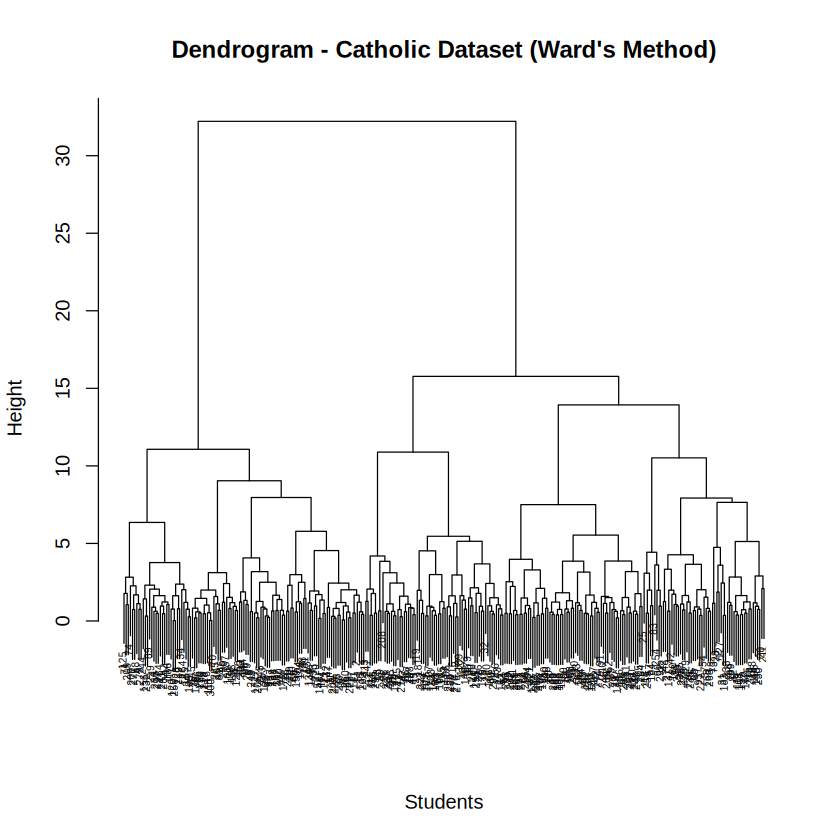

In [9]:
plot(hc,
     main = "Dendrogram - Catholic Dataset (Ward's Method)",
     xlab = "Students", sub = "", cex = 0.5)


In [10]:
clusters_hc <- cutree(hc, k = 3)
clusters_hc

[1] 1 1 1 1 1 1 2 2 1 1 1 2 3 1 2 1 1 2 3 2 3 2 2 1 2 1 2 2 2 3 2 3 1 1 2 1 2
 [38] 1 2 3 1 2 3 3 2 1 3 2 3 3 1 1 1 2 2 3 2 1 2 3 2 3 2 2 2 3 3 2 1 1 1 2 2 1
 [75] 1 3 1 1 2 2 1 2 2 2 2 1 1 1 1 2 2 1 2 2 1 3 3 1 3 2 1 3 2 1 1 2 2 3 3 2 3
[112] 2 3 1 1 2 1 2 1 1 1 3 2 1 1 2 2 1 1 1 2 1 1 1 3 2 1 1 1 3 1 2 3 1 1 3 1 1
[149] 1 1 2 3 1 3 3 1 2 2 1 2 3 2 2 1 3 3 1 2 2 2 3 1 3 2 1 3 1 1 3 2 3 2 2 2 1
[186] 1 2 3 3 2 2 2 1 2 2 2 2 2 2 1 1 1 3 2 2 1 2 3 1 2 2 2 2 3 1 3 1 1 1 1 2 3
[223] 3 1 2 3 2 1 2 2 1 2 2 1 2 1 2 1 2 2 1 2 3 1 1 2 3 2 1 1 2 2 1 2 2 2 2 3 2
[260] 1 2 2 1 2 2 2 3 2 2 3 3 2 1 2 2 3 1 2 2 1 1 1 1 2 1 3 3 3 1 3 2 3 2 3 3 3
[297] 1 2 1 1

In [11]:
table(clusters_hc)

clusters_hc
  1   2   3 
113 122  65 

In [12]:
#KMeans

In [13]:
library(dplyr)

In [15]:
df <- read.csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/catholic.csv")


In [16]:
str(df)
head(df)
dim(df)

'data.frame':	7430 obs. of  14 variables:
 $ rownames: int  1 2 3 4 5 6 7 8 9 10 ...
 $ id      : int  124902 124915 124916 124932 124944 124947 124966 124968 124972 124974 ...
 $ read12  : num  61.4 58.3 59.3 49.6 57.6 ...
 $ math12  : num  49.8 59.8 50.4 45 54.3 ...
 $ female  : int  0 0 1 1 1 1 1 0 0 0 ...
 $ asian   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispan  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ black   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ motheduc: num  14 14 14 12 12 12 14 14 14 14 ...
 $ fatheduc: num  12 14 11 14 12 11 14 14 14 12 ...
 $ lfaminc : num  10.3 10.3 10.3 10.3 10.7 ...
 $ hsgrad  : int  1 1 1 1 1 1 1 1 1 1 ...
 $ cathhs  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ parcath : int  1 1 1 1 1 1 1 1 1 1 ...


,rownames,id,read12,math12,female,asian,hispan,black,motheduc,fatheduc,lfaminc,hsgrad,cathhs,parcath
,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,1,124902,61.41,49.77,0,0,0,0,14,12,10.30895,1,0,1
2,2,124915,58.34,59.84,0,0,0,0,14,14,10.30895,1,0,1
3,3,124916,59.33,50.38,1,0,0,0,14,11,10.30895,1,0,1
4,4,124932,49.59,45.03,1,0,0,0,12,14,10.30895,1,0,1
5,5,124944,57.62,54.26,1,0,0,0,12,12,10.65726,1,0,1
6,6,124947,52.53,56.73,1,0,0,0,12,11,11.04292,1,0,1


[1] 7430   14

In [17]:
colSums(is.na(df))

rownames       id   read12   math12   female    asian   hispan    black 
       0        0        0        0        0        0        0        0 
motheduc fatheduc  lfaminc   hsgrad   cathhs  parcath 
       0        0        0     1460        0        0

In [18]:
table(df$cathhs)



   0    1 
6978  452 

In [19]:

km_data <- df %>% select(read12, math12, motheduc, fatheduc, lfaminc)


In [20]:
km_scaled <- scale(km_data)

In [21]:
set.seed(123)
kmeans_2 <- kmeans(km_scaled, centers = 2, nstart = 25)

In [22]:
print(kmeans_2)

K-means clustering with 2 clusters of sizes 3843, 3587

Cluster means:
      read12     math12   motheduc   fatheduc    lfaminc
1  0.6346828  0.6681287  0.4998803  0.5479206  0.4407891
2 -0.6799794 -0.7158123 -0.5355562 -0.5870251 -0.4722478

Clustering vector:
   [1] 1 1 2 2 1 2 1 1 2 1 2 2 1 2 2 1 1 1 1 2 1 1 1 1 1 2 2 2 2 2 2 1 1 2 2 2 2
  [38] 1 1 1 1 1 1 1 1 2 2 1 2 1 1 2 1 2 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 1
  [75] 1 1 2 2 2 2 1 1 1 1 1 2 1 2 1 1 1 1 1 2 2 2 1 2 1 1 2 2 2 1 1 1 1 1 2 1 2
 [112] 1 2 2 1 1 1 1 2 1 1 2 1 1 1 2 2 1 1 2 2 2 2 2 2 1 2 2 2 2 1 2 1 1 2 1 1 2
 [149] 2 2 1 1 2 2 1 2 1 2 1 2 2 1 1 1 1 1 1 2 1 2 2 2 2 2 1 1 2 2 2 2 1 2 1 1 2
 [186] 2 1 1 1 1 1 1 2 2 2 2 1 2 2 2 1 1 1 2 2 1 2 2 2 2 2 2 1 2 1 1 2 2 2 1 2 2
 [223] 2 1 1 2 2 2 2 2 2 2 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 2 2 1
 [260] 2 1 2 2 1 2 2 1 1 1 1 1 1 1 2 2 1 2 2 2 2 1 1 1 2 1 2 1 1 2 2 1 2 1 1 1 1
 [297] 2 1 2 1 2 1 1 1 1 1 1 1 2 1 2 2 1 2 2 2 1 2 2 2 2 2 1 1 1 1 1 2 1 2 2 2 2
 [334] 2 

In [23]:
kmeans_2$centers


,read12,math12,motheduc,fatheduc,lfaminc
1,0.6346828,0.6681287,0.4998803,0.5479206,0.4407891
2,-0.6799794,-0.7158123,-0.5355562,-0.5870251,-0.4722478


In [24]:
wcss <- vector("numeric", 10)
for (k in 1:10) {
  set.seed(123)
  km_model <- kmeans(km_scaled, centers = k, nstart = 25)
  wcss[k] <- km_model$tot.withinss
}
wcss

Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 371500)”
Warning message:
“did not converge in 10 iterations”


[1] 37145.00 24459.43 20696.94 17639.54 16228.23 15052.02 14064.44 13368.86
 [9] 12726.75 12103.34

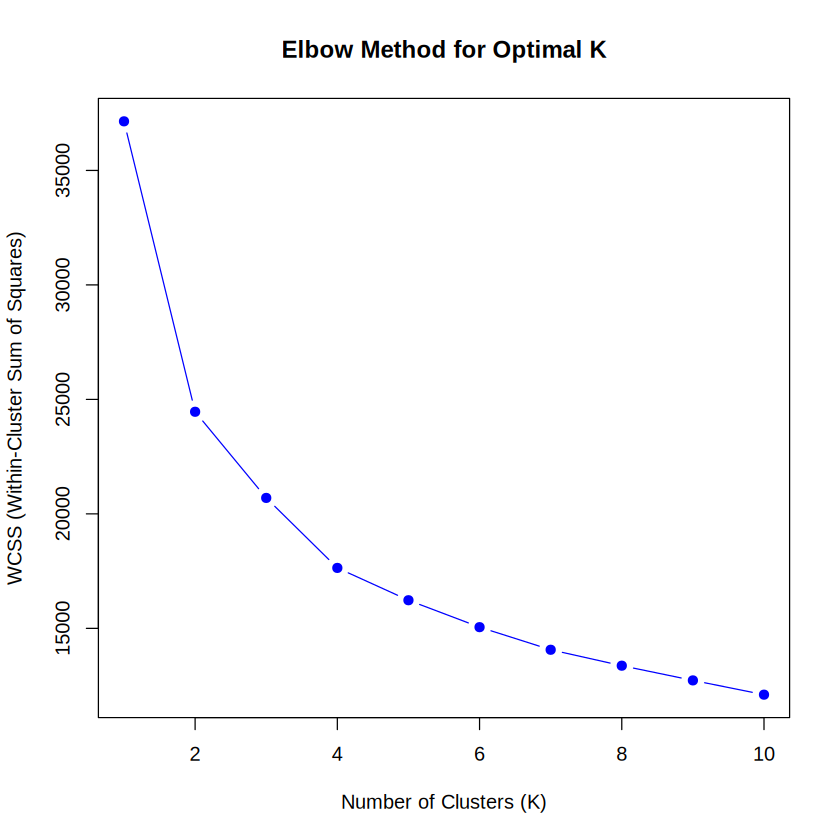

In [25]:
plot(1:10, wcss, type = "b", pch = 19, col = "blue",
     xlab = "Number of Clusters (K)",
     ylab = "WCSS (Within-Cluster Sum of Squares)",
     main = "Elbow Method for Optimal K")

In [26]:
optimal_k <- 3   # <-- adjust after viewing the elbow plot

set.seed(123)
kmeans_final <- kmeans(km_scaled, centers = optimal_k, nstart = 25)

print(kmeans_final)
kmeans_final$centers
table(kmeans_final$cluster)

K-means clustering with 3 clusters of sizes 2490, 2904, 2036

Cluster means:
      read12     math12   motheduc   fatheduc     lfaminc
1 -1.0403408 -1.0121690 -0.5435733 -0.6039963 -0.56815634
2  0.4403819  0.3329668 -0.2267380 -0.2497474 -0.02302937
3  0.6441944  0.7629495  0.9881850  1.0949004  0.72769478

Clustering vector:
   [1] 2 2 2 1 2 2 2 2 2 2 2 2 2 1 1 3 2 3 2 2 2 3 3 3 3 2 1 1 1 2 1 3 3 1 1 1 2
  [38] 3 3 2 3 3 3 3 3 2 1 3 1 3 2 1 2 2 3 1 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 2
  [75] 3 2 1 1 1 1 3 2 3 2 3 1 3 1 3 3 3 2 2 2 1 1 3 1 2 2 1 1 2 3 2 3 3 3 2 2 2
 [112] 3 1 2 3 3 3 2 2 2 2 2 2 2 3 1 1 3 2 1 1 1 1 1 1 3 1 1 1 2 2 2 2 2 2 2 2 1
 [149] 2 2 2 3 1 2 2 2 3 2 3 2 2 3 3 2 2 2 2 2 2 2 1 1 1 2 3 3 1 1 1 1 3 2 2 2 2
 [186] 1 3 3 2 2 2 2 1 2 1 2 3 1 2 2 2 3 3 1 1 2 1 1 1 1 1 1 2 1 2 3 2 1 1 3 2 1
 [223] 1 2 3 1 1 1 2 2 1 1 2 1 3 1 2 2 1 2 2 1 2 1 3 2 3 1 3 2 2 2 2 1 1 2 2 1 2
 [260] 1 3 1 1 2 2 2 2 2 2 3 2 2 3 1 2 2 2 1 1 2 2 3 2 2 2 1 3 2 1 1 2 1 2 2 3 2
 [297] 2 2 2 3 1 2 2 3 

,read12,math12,motheduc,fatheduc,lfaminc
1,-1.0403408,-1.0121690,-0.5435733,-0.6039963,-0.56815634
2,0.4403819,0.3329668,-0.2267380,-0.2497474,-0.02302937
3,0.6441944,0.7629495,0.9881850,1.0949004,0.72769478



   1    2    3 
2490 2904 2036 